In [ ]:
! pip install selenium beautifulsoup4 pandas numpy requests lxml openpyxl

In [ ]:
import os
print(os.getcwd())

c:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\01_DataAnalysis\scripts\preprocessing


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re


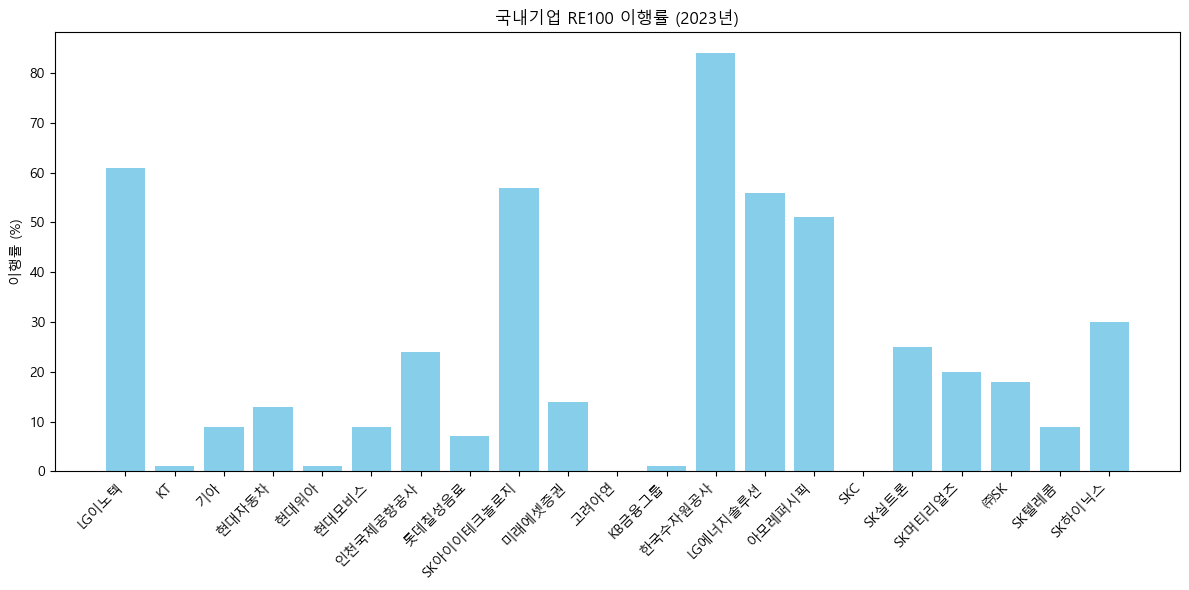

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# 국내 기업 RE100 이행률 막대 그래프
df = pd.read_csv(r"C:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\01_DataAnalysis\results\tables\k_re100_companies_all.csv")

df['RE100 달성률'] = df['RE100 목표/달성률'].str.extract(r'\((\d+)%\)')[0].astype(int)

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False


plt.figure(figsize=(12,6))
plt.bar(df['기업명'], df['RE100 달성률'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("국내기업 RE100 이행률 (2023년)")
plt.ylabel("이행률 (%)")
plt.tight_layout()

plt.show()

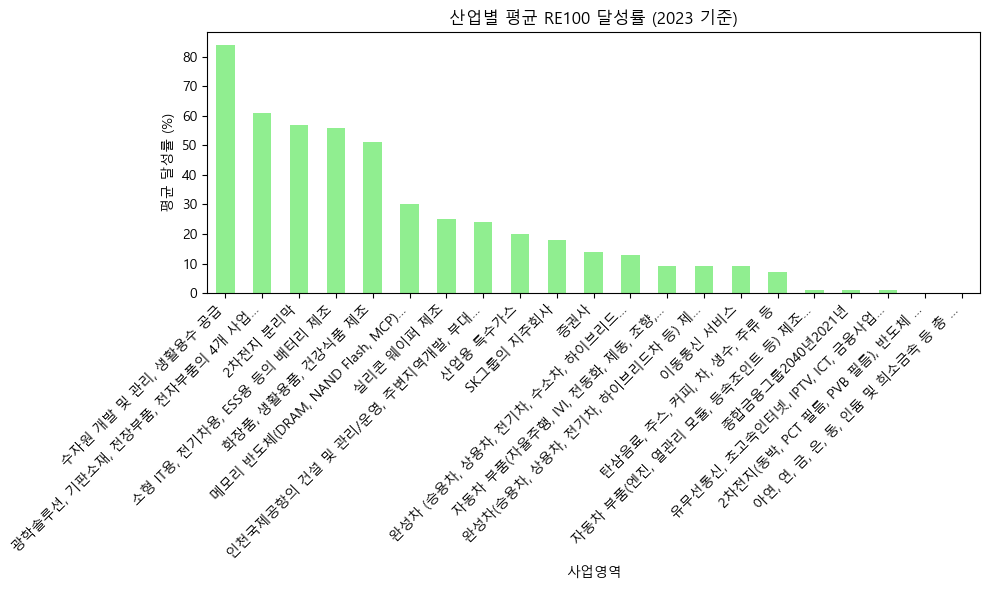

In [ ]:
# 산업별 평균 RE100 달성률

industry_avg = df.groupby("사업영역")["RE100 달성률"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
industry_avg.plot(kind="bar", color="lightgreen")
plt.title("산업별 평균 RE100 달성률 (2023 기준)")
plt.ylabel("평균 달성률 (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

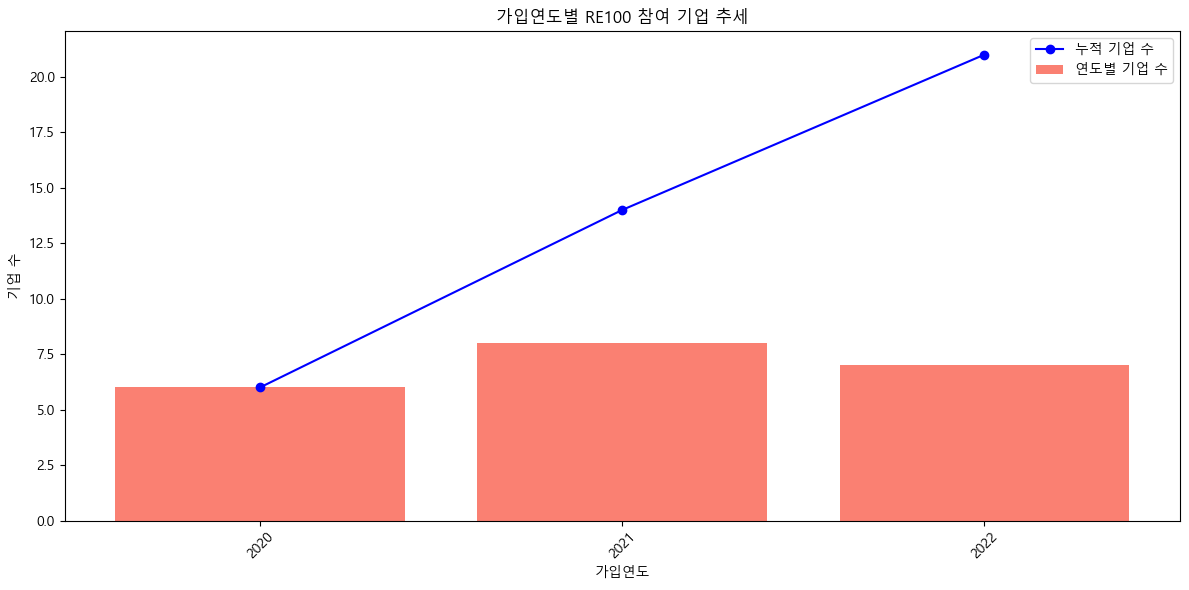

In [3]:
import matplotlib.pyplot as plt
import pandas as pd


join_counts = df['가입연도'].value_counts().sort_index()


years = range(join_counts.index.min(), join_counts.index.max()+1)

plt.figure(figsize=(12,6))
plt.bar(join_counts.index, join_counts.values, color="salmon", label="연도별 기업 수")

cumsum = join_counts.cumsum()
plt.plot(join_counts.index, cumsum, color="blue", marker="o", label="누적 기업 수")

plt.xticks(years, rotation=45)

plt.title("가입연도별 RE100 참여 기업 추세")
plt.xlabel("가입연도")
plt.ylabel("기업 수")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\dkreh\AppData\Local\Temp\ipykernel_7268\3028246084.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="재생에너지 사용률(%)", y="국가", data=df, palette=colors)


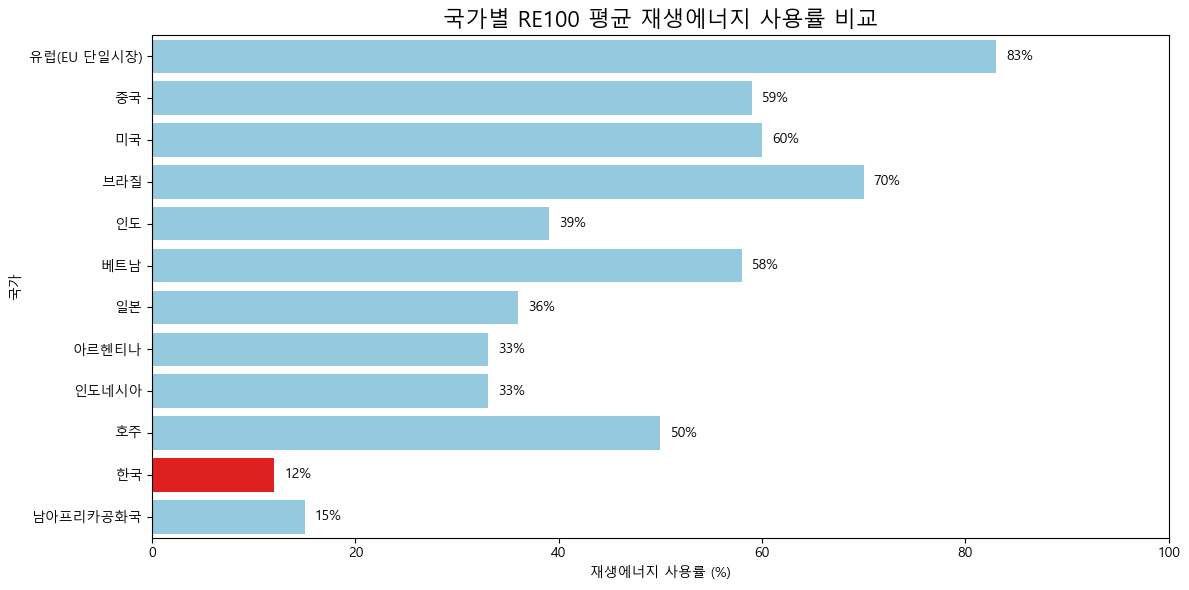

In [ ]:
# 해외 사례 비교
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False


data = {
    "국가": [
        "유럽(EU 단일시장)", "중국", "미국", "브라질", "인도",
        "베트남", "일본", "아르헨티나", "인도네시아", "호주",
        "한국", "남아프리카공화국"
    ],
    "재생에너지 사용률(%)": [83, 59, 60, 70, 39, 58, 36, 33, 33, 50, 12, 15]
}

df = pd.DataFrame(data)

colors = [] # 추가 : 한국만 색 바꿈
for country in df["국가"]:
    if country == "한국":
        colors.append("red")
    else:
        colors.append("skyblue")


plt.figure(figsize=(12, 6))
sns.barplot(x="재생에너지 사용률(%)", y="국가", data=df, palette=colors)


for index, value in enumerate(df["재생에너지 사용률(%)"]):
    plt.text(value + 1, index, str(value) + "%", va='center')

plt.title("국가별 RE100 평균 재생에너지 사용률 비교", fontsize=16)
plt.xlabel("재생에너지 사용률 (%)")
plt.ylabel("국가")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


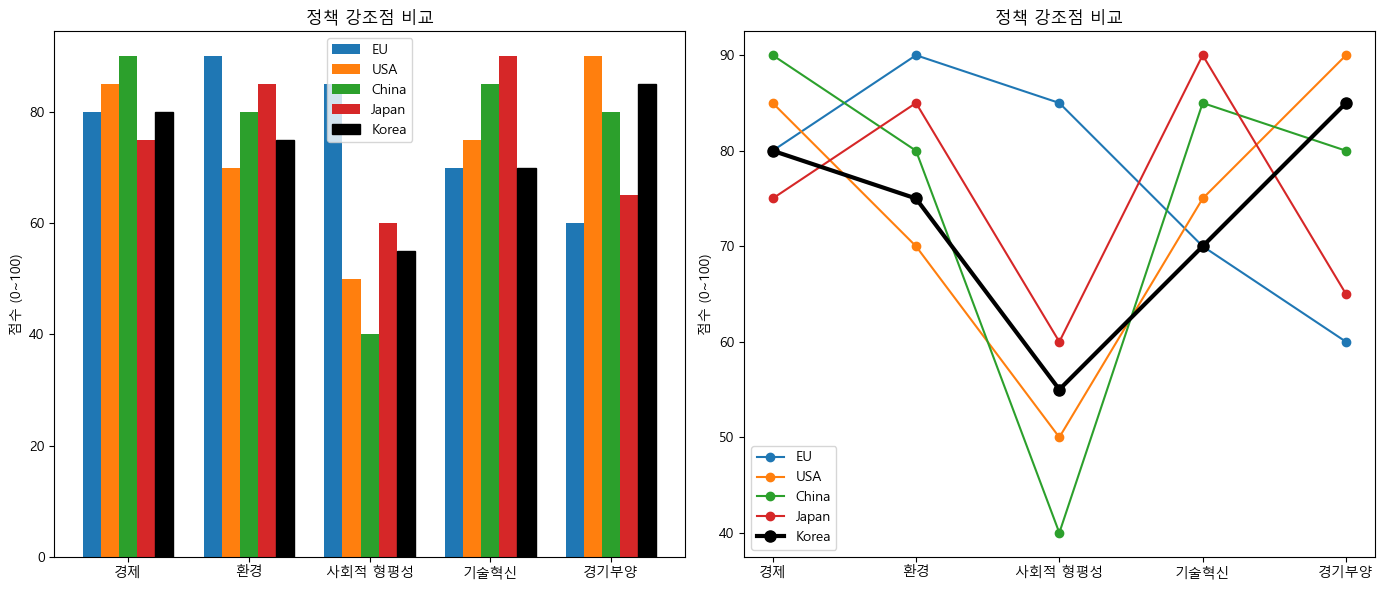

In [ ]:
# 그린뉴딜 국내와 해외 비교

import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 지표와 데이터
labels = ['경제', '환경', '사회적 형평성', '기술혁신', '경기부양']
EU = [80, 90, 85, 70, 60]
USA = [85, 70, 50, 75, 90]
China = [90, 80, 40, 85, 80]
Japan = [75, 85, 60, 90, 65]
Korea = [80, 75, 55, 70, 85]

data = [EU, USA, China, Japan, Korea]
countries = ['EU', 'USA', 'China', 'Japan', 'Korea']

x = np.arange(len(labels))
width = 0.15                


fig, axes = plt.subplots(1, 2, figsize=(14,6))

for i, country in enumerate(countries):
    if country == 'Korea':
        axes[0].bar(x + i*width, data[i], width, label=country, color="#000000", edgecolor='black')
    else:
        axes[0].bar(x + i*width, data[i], width, label=country)

axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('점수 (0~100)')
axes[0].set_title('정책 강조점 비교')
axes[0].legend()


for i, country in enumerate(countries):
    if country == 'Korea':
        axes[1].plot(labels, data[i], marker='o', label=country,
                     color='#000000', linewidth=3, markersize=8)
    else:
        axes[1].plot(labels, data[i], marker='o', label=country)

axes[1].set_ylabel('점수 (0~100)')
axes[1].set_title('정책 강조점 비교')
axes[1].legend()

plt.tight_layout()
plt.show()

#-----------------------------
# 출처 한국 학술지 용인 색인
#-----------------------------

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


url = "https://www.keei.re.kr/board.es?mid=a20102000000&bid=0028&act=view&list_no=119352&cg_code=C01"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")


data = {
    "Year": [2025, 2030],
    "EU_Target_Reduction(%)": [55, 100], 
    "Korea_Target_Reduction(%)": [24.4, 40],
    "Korea_Contribution_GreenNewDeal(%)": [3.3, 10] 
}
df = pd.DataFrame(data)


sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
sns.barplot(x="Year", y="value", hue="variable",
            data=pd.melt(df, ["Year"], var_name="variable", value_name="value"))

plt.title("EU vs Korea Green New Deal GHG Reduction Contribution")
plt.ylabel("Reduction (%)")
plt.xlabel("Year")
plt.legend(title="Category")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("현재 작업 디렉토리:", os.getcwd())

df = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/docs/강원도_지역별_재생에너지_발전량.xlsx", sheet_name="Sheet1")

print(df.head())

현재 작업 디렉토리: c:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\01_DataAnalysis\scripts\preprocessing
     연도 광역지자체 기초지자체  신재생에너지 합계   재생에너지 합계  신에너지 합계  신재생에너지공급비중      태양광  \
0  2021    강원   강릉시  2,088,289  2,088,224       65       35.46  131,258   
1  2021    강원   고성군    142,575    142,575        -        2.42  141,704   
2  2021    강원    기타      4,429      4,403       26        0.08    2,769   
3  2021    강원   동해시    405,359    273,611  131,748        6.88   26,993   
4  2021    강원   삼척시    280,341    280,337        3        4.76  110,382   

       풍력      수력 해양        바이오 재생폐기물     연료전지 IGCC  
0  81,395   3,230  -  1,872,341     -       65    -  
1       -     871  -          -     -        -    -  
2   1,634       -  -          -     -       26    -  
3       -  30,284  -    216,335     -  131,748    -  
4  33,271  13,449  -    123,235     -        3    -  


In [ ]:
! pip install selenium beautifulsoup4 pandas numpy requests lxml openpyxl

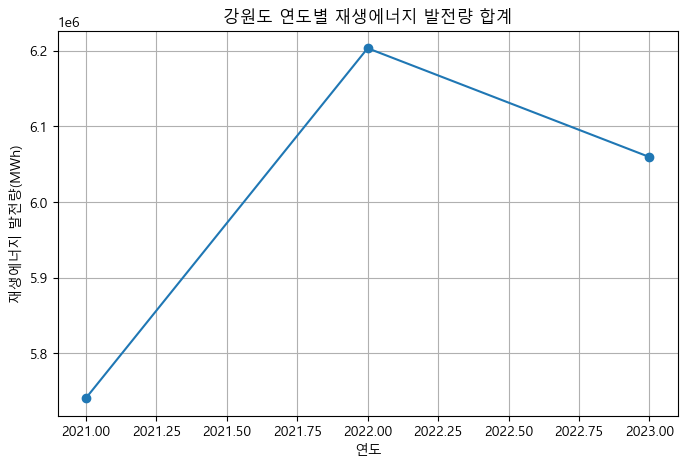

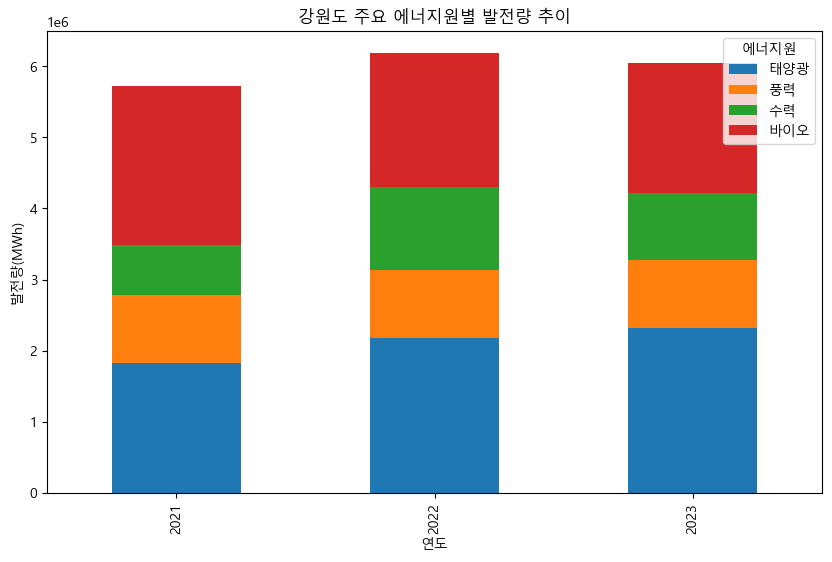

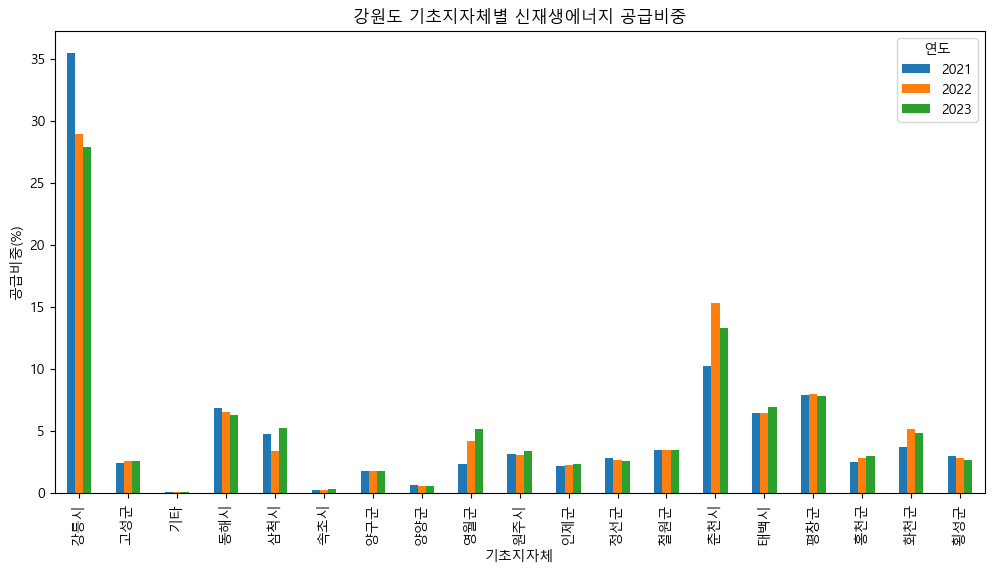

📊 강원도 연도별 재생에너지 발전량 합계(MWh):
2021년: 5,740,642 MWh
2022년: 6,203,410 MWh
2023년: 6,059,528 MWh


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False


df = pd.read_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/docs/강원도_지역별_재생에너지_발전량.xlsx",
    sheet_name="Sheet1"
)


df["연도"] = pd.to_numeric(df["연도"], errors="coerce")
df["재생에너지 합계"] = (
    df["재생에너지 합계"].astype(str)
    .str.replace(",", "")
    .str.replace("-", "0")
    .astype(float)
)

for col in ["태양광", "풍력", "수력", "바이오"]:
    df[col] = (
        df[col].astype(str)
        .str.replace(",", "")
        .str.replace("-", "0")
        .astype(float)
    )


yearly_sum = df.groupby("연도")["재생에너지 합계"].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly_sum.index, yearly_sum.values, marker="o")
plt.title("강원도 연도별 재생에너지 발전량 합계")
plt.xlabel("연도")
plt.ylabel("재생에너지 발전량(MWh)")
plt.grid(True)
plt.show()


energy_sources = ["태양광", "풍력", "수력", "바이오"]
yearly_sources = df.groupby("연도")[energy_sources].sum()

yearly_sources.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("강원도 주요 에너지원별 발전량 추이")
plt.xlabel("연도")
plt.ylabel("발전량(MWh)")
plt.legend(title="에너지원")
plt.show()


pivot_ratio = df.pivot_table(index="기초지자체", columns="연도", values="신재생에너지공급비중")

pivot_ratio.plot(kind="bar", figsize=(12,6))
plt.title("강원도 기초지자체별 신재생에너지 공급비중")
plt.xlabel("기초지자체")
plt.ylabel("공급비중(%)")
plt.legend(title="연도")
plt.show()

print("📊 강원도 연도별 재생에너지 발전량 합계(MWh):")
for year, value in yearly_sum.items():
    print(f"{year}년: {value:,.0f} MWh")

C:\Users\dkreh\AppData\Local\Temp\ipykernel_20092\1591248965.py:49: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) Arial.
  plt.savefig(output_path, bbox_inches='tight')
C:\Users\dkreh\AppData\Local\Temp\ipykernel_20092\1591248965.py:49: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) Arial.
  plt.savefig(output_path, bbox_inches='tight')
C:\Users\dkreh\AppData\Local\Temp\ipykernel_20092\1591248965.py:49: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.savefig(output_path, bbox_inches='tight')
C:\Users\dkreh\AppData\Local\Temp\ipykernel_20092\1591248965.py:49: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  plt.savefig(output_path, bbox_inches='tight')
C:\Users\dkreh\AppData\Local\Temp\ipykernel_20092\1591248965.py:49: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  plt.savefig(output_path, bbox_inches='tight')
C:\Users\dkreh\AppData\Loc

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\dkreh\\Desktop\\KDT_RE_5th\\3_Project\\01_DataAnalysis\\results\\figure/sgreen_new_deal_radar_korean.png'

c:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\dk

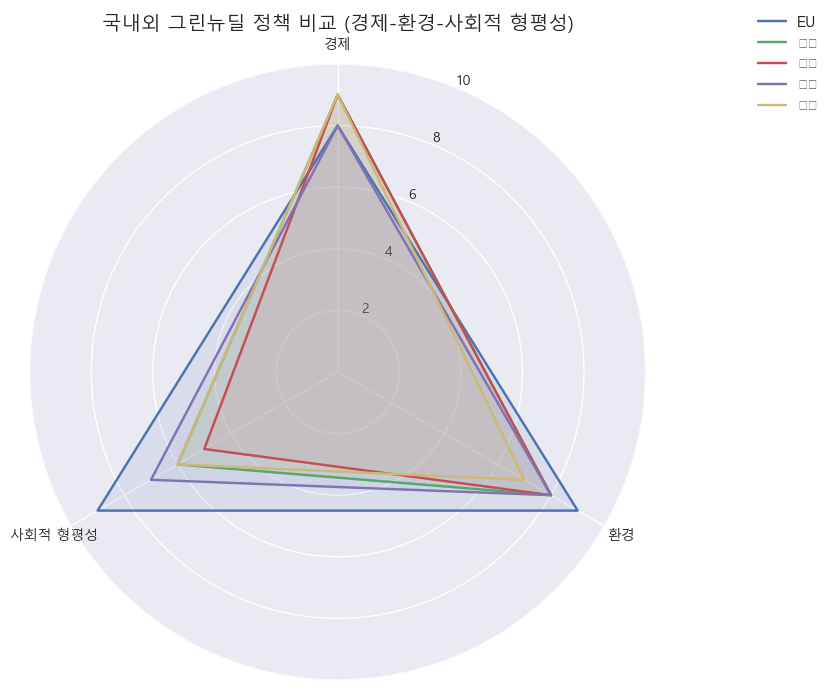

In [ ]:
# 국가별 비교 추세 그래프
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import os

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams['font.family'] = 'AppleGothic' if 'AppleGothic' in fm.findSystemFonts(fontpaths=None, fontext='ttf') else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


labels = ['경제', '환경', '사회적 형평성']
num_vars = len(labels)

data = {
    'EU': [8, 9, 9],
    '미국': [9, 8, 6],
    '중국': [9, 8, 5],
    '일본': [8, 8, 7],
    '한국': [9, 7, 6]
}


angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # complete the loop


fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.style.use('seaborn-v0_8')


for country, values in data.items():
    values += values[:1]  # complete the loop
    ax.plot(angles, values, label=country)
    ax.fill(angles, values, alpha=0.1)


ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title('국내외 그린뉴딜 정책 비교 (경제-환경-사회적 형평성)', fontsize=14)
ax.set_ylim(0, 10)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))


output_path = r"C:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\01_DataAnalysis\results\figure/sgreen_new_deal_radar_korean.png"
plt.savefig(output_path, bbox_inches='tight')

print("레이더 차트를 생성하고 'green_new_deal_radar_korean.png'로 저장했습니다.")


국가별 그린뉴딜 투자 규모와 2030년 온실가스 감축 목표를 비교한 복합 그래프를 생성하고 저장했습니다.


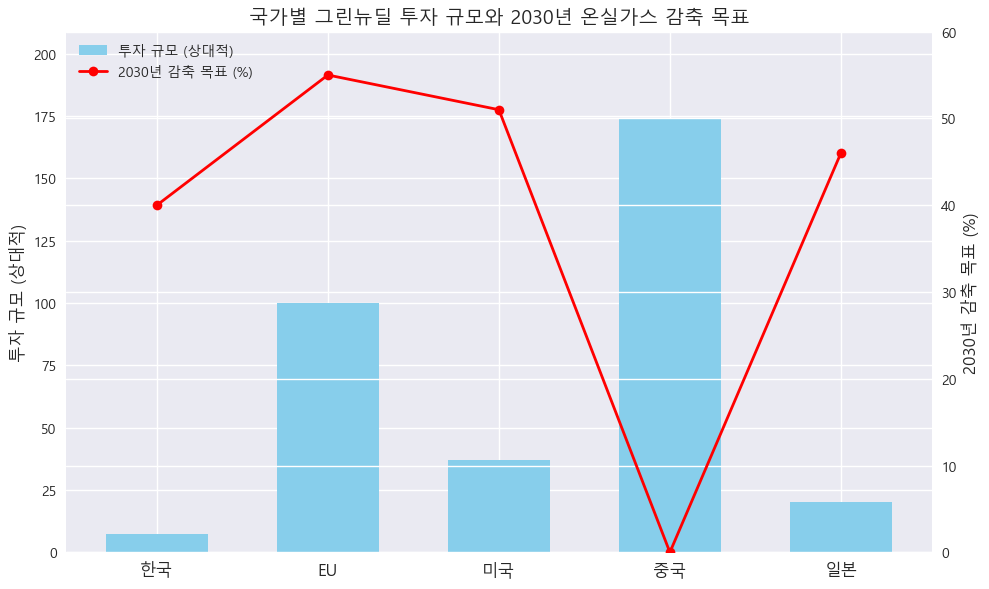

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('seaborn-v0_8')
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

countries = ['한국', 'EU', '미국', '중국', '일본']
investment_relative = [7.3, 100, 36.9, 174, 20]  
reduction_targets = [40, 55, 51, 0, 46]  

x = np.arange(len(countries))
width = 0.6

fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(x, investment_relative, width, color='skyblue', label='투자 규모 (상대적)')
ax1.set_ylabel('투자 규모 (상대적)', fontsize=12)
ax1.set_ylim(0, max(investment_relative) * 1.2)

ax2 = ax1.twinx()
line = ax2.plot(x, reduction_targets, color='red', marker='o', linewidth=2, label='2030년 감축 목표 (%)')
ax2.set_ylabel('2030년 감축 목표 (%)', fontsize=12)
ax2.set_ylim(0, 60)

ax1.set_xticks(x)
ax1.set_xticklabels(countries, fontsize=12)

plt.title('국가별 그린뉴딜 투자 규모와 2030년 온실가스 감축 목표', fontsize=14)
lines_labels = [bars, line[0]]
labels = [l.get_label() for l in lines_labels]
ax1.legend(lines_labels, labels, loc='upper left')

output_path = r"C:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\01_DataAnalysis\results\figures/green_new_deal_comparison.png"
plt.tight_layout()
plt.savefig(output_path)

print("국가별 그린뉴딜 투자 규모와 2030년 온실가스 감축 목표를 비교한 복합 그래프를 생성하고 저장했습니다.")


국내외 그린뉴딜 정책은 각국의 경제 상황과 사회적 요구에 따라 차별화된 전략을 추진한다. 
>EU : 경제·환경·사회적 형평성을 균형 있게 고려하며 2050년 탄소중립을 목표로 한다.

>미국 :  인플레이션 감축법(IRA)을 통해 대규모 투자를 진행하며 일자리 창출과 에너지 전환을 강조한다. 한국 :  코로나19 이후 경기 회복과 일자리 중심의 정책을 추진한다. 

>일본 :  산업별 녹색성장 전략과 강력한 규제를 병행한다.

>중국 : 세계 최대 규모의 재생에너지와 전기차 시장을 기반으로 기술·산업 중심의 생태문명 건설을 추진한다.

| 국가 | 투자 규모 (대략) | 감축 목표 (2030) | 최종 목표 | 정책 특징 |
|------|------------------|------------------|-----------|-----------|
| EU | 1조 유로 이상 (2021~2027) | 1990년 대비 55% 감축 | 2050년 탄소중립 | 경제·환경·사회 균형, 탄소국경세, 재생에너지·농식품 전략 |
| 미국 | 3690억 달러 (IRA, 2022) | 2005년 대비 50~52% 감축 | 2050년 탄소중립 | 일자리 창출, 전기차·철도 인프라, 청정에너지 확대 |
| 한국 | 73.4조 원 (2020~2025) | 2018년 대비 40% 감축 | 2050년 탄소중립 | 경기 회복, 일자리 중심, 디지털·그린 인프라 투자 |
| 일본 | 수십조 엔 (녹색성장 전략) | 2013년 대비 46% 감축 | 2050년 탄소중립 | 산업별 녹색성장 전략, 강력한 환경 규제, 수소·풍력 확대 |
| 중국 | 174조 위안 (2030까지) | 2030년 배출 정점 | 2060년 탄소중립 | 세계 최대 재생에너지·전기차 시장, 스마트시티·산업 중심 |
